# Analisis Data Rumah Sakit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Load Dataset

In [2]:

# Membaca dataset yang tersedia
df = pd.read_csv('dataset_RS.csv')
print("\n--- 5 Data Pertama ---")
display(df.head())



--- 5 Data Pertama ---


,id_kunjungan,tanggal,umur,jenis_kelamin,asuransi,status_pasien,prioritas,nama_poli,nama_dokter,kode_icd,diagnosis,waktu_kedatangan,waktu_registrasi,waktu_mulai_layanan,waktu_selesai_layanan,durasi_layanan,waktu_tunggu,jumlah_antrian,biaya,kepuasan_pasien
0,KJ-17479,2025-02-27,37.0,P,BPJS,Rawat Jalan,Normal,Poli Jantung,Dewi Lestari,I25,Jantung Koroner,2025-02-27 09:54:00,2025-02-27 09:59:00,2025-02-27 10:44:00,2025-02-27 10:58:00,14,45,21,5726,3
1,KJ-18387,2025-06-04,13.0,P,Umum,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K05,Gingivitis,2025-06-04 13:15:00,2025-06-04 13:17:00,2025-06-04 13:28:00,2025-06-04 13:58:00,30,11,6,476067,5
2,KJ-17377,2025-01-29,40.0,P,Umum,Rawat Jalan,Normal,Poli Kandungan,Maya Sari,Z01,Kontrol Kehamilan,2025-01-29 13:53:00,2025-01-29 13:56:00,2025-01-29 14:09:00,2025-01-29 14:22:00,13,13,8,242783,1
3,KJ-22127,2025-04-24,40.0,L,BPJS,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K02,Karies,2025-04-24 13:02:00,2025-04-24 13:09:00,2025-04-24 13:14:00,2025-04-24 13:24:00,10,5,0,146541,4
4,KJ-18784,2025-04-02,70.0,P,BPJS,Rawat Jalan,Normal,Poli Kandungan,Maya Sari,Z34,Kehamilan,2025-04-02 10:09:00,2025-04-02 10:14:00,2025-04-02 10:43:00,2025-04-02 11:03:00,20,29,12,2966,1


### Cek Info Data

In [3]:

# Menampilkan informasi dasar dataset
print("--- Info Dataset ---")
print(df.info())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20215 entries, 0 to 20214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_kunjungan           20215 non-null  object 
 1   tanggal                20215 non-null  object 
 2   umur                   19811 non-null  float64
 3   jenis_kelamin          20215 non-null  object 
 4   asuransi               20215 non-null  object 
 5   status_pasien          20215 non-null  object 
 6   prioritas              20215 non-null  object 
 7   nama_poli              20215 non-null  object 
 8   nama_dokter            20215 non-null  object 
 9   kode_icd               20215 non-null  object 
 10  diagnosis              20215 non-null  object 
 11  waktu_kedatangan       20215 non-null  object 
 12  waktu_registrasi       20215 non-null  object 
 13  waktu_mulai_layanan    20215 non-null  object 
 14  waktu_selesai_layanan  20215 non-

### Ubah tipe data

In [4]:
cols_to_convert = [
    'tanggal',
    'waktu_kedatangan',
    'waktu_registrasi',
    'waktu_mulai_layanan',
    'waktu_selesai_layanan'
]

for col in cols_to_convert:
    df[col] = pd.to_datetime(df[col])

# Memverifikasi perubahan tipe data
print("--- Tipe Data Setelah Konversi ---")
print(df[cols_to_convert].dtypes)
display(df.head())

--- Tipe Data Setelah Konversi ---
tanggal                  datetime64[ns]
waktu_kedatangan         datetime64[ns]
waktu_registrasi         datetime64[ns]
waktu_mulai_layanan      datetime64[ns]
waktu_selesai_layanan    datetime64[ns]
dtype: object


,id_kunjungan,tanggal,umur,jenis_kelamin,asuransi,status_pasien,prioritas,nama_poli,nama_dokter,kode_icd,diagnosis,waktu_kedatangan,waktu_registrasi,waktu_mulai_layanan,waktu_selesai_layanan,durasi_layanan,waktu_tunggu,jumlah_antrian,biaya,kepuasan_pasien
0,KJ-17479,2025-02-27,37.0,P,BPJS,Rawat Jalan,Normal,Poli Jantung,Dewi Lestari,I25,Jantung Koroner,2025-02-27 09:54:00,2025-02-27 09:59:00,2025-02-27 10:44:00,2025-02-27 10:58:00,14,45,21,5726,3
1,KJ-18387,2025-06-04,13.0,P,Umum,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K05,Gingivitis,2025-06-04 13:15:00,2025-06-04 13:17:00,2025-06-04 13:28:00,2025-06-04 13:58:00,30,11,6,476067,5
2,KJ-17377,2025-01-29,40.0,P,Umum,Rawat Jalan,Normal,Poli Kandungan,Maya Sari,Z01,Kontrol Kehamilan,2025-01-29 13:53:00,2025-01-29 13:56:00,2025-01-29 14:09:00,2025-01-29 14:22:00,13,13,8,242783,1
3,KJ-22127,2025-04-24,40.0,L,BPJS,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K02,Karies,2025-04-24 13:02:00,2025-04-24 13:09:00,2025-04-24 13:14:00,2025-04-24 13:24:00,10,5,0,146541,4
4,KJ-18784,2025-04-02,70.0,P,BPJS,Rawat Jalan,Normal,Poli Kandungan,Maya Sari,Z34,Kehamilan,2025-04-02 10:09:00,2025-04-02 10:14:00,2025-04-02 10:43:00,2025-04-02 11:03:00,20,29,12,2966,1


### Tangani Duplicate Data

In [5]:
# Mengecek jumlah baris duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

# Jika ada duplikat, tampilkan contoh datanya
if duplicate_count > 0:
    display(df[df.duplicated()].head())

Jumlah data duplikat: 215


,id_kunjungan,tanggal,umur,jenis_kelamin,asuransi,status_pasien,prioritas,nama_poli,nama_dokter,kode_icd,diagnosis,waktu_kedatangan,waktu_registrasi,waktu_mulai_layanan,waktu_selesai_layanan,durasi_layanan,waktu_tunggu,jumlah_antrian,biaya,kepuasan_pasien
458,KJ-26588,2025-04-27,67.0,P,BPJS,Rawat Jalan,Normal,Poli Umum,Andi Santoso,K29,Gastritis,2025-04-27 09:02:00,2025-04-27 09:09:00,2025-04-27 09:48:00,2025-04-27 10:02:00,14,39,16,52464,1
709,KJ-13231,2025-04-17,8.0,P,BPJS,Rawat Jalan,Normal,Poli Anak,Budi Hermawan,J06.9,ISPA Anak,2025-04-17 12:35:00,2025-04-17 12:43:00,2025-04-17 12:56:00,2025-04-17 13:23:00,27,13,3,79874,2
881,KJ-29281,2025-05-09,12.0,P,BPJS,Rawat Jalan,Normal,Poli Anak,Rina Kartika,J06.9,ISPA Anak,2025-05-09 07:38:00,2025-05-09 07:42:00,2025-05-09 07:53:00,2025-05-09 08:11:00,18,11,4,148689,2
922,KJ-12384,2025-02-15,15.0,L,BPJS,Rawat Jalan,Normal,Poli Penyakit Dalam,Rizky Pratama,M10,Asam Urat,2025-02-15 14:41:00,2025-02-15 14:51:00,2025-02-15 15:13:00,2025-02-15 15:30:00,17,22,11,70854,3
1457,KJ-15828,2025-04-30,40.0,L,Umum,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K02,Karies,2025-04-30 10:46:00,2025-04-30 10:50:00,2025-04-30 11:17:00,2025-04-30 11:45:00,28,27,18,493372,3


In [6]:
# Menghapus baris duplikat dan menyimpan dataset yang bersih
df = df.drop_duplicates()

# Menampilkan jumlah baris setelah pembersihan
print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")
print(f"Cek kembali jumlah duplikat: {df.duplicated().sum()}")

Jumlah baris setelah menghapus duplikat: 20000
Cek kembali jumlah duplikat: 0


### Tangani Missing Values

In [7]:
# Mengecek missing values per kolom
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Menggabungkan hasil ke dalam satu DataFrame untuk kemudahan pembacaan
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

print("--- Ringkasan Missing Values ---")
display(missing_df[missing_df['Missing Values'] > 0] if missing_values.sum() > 0 else "Tidak ada missing values.")

--- Ringkasan Missing Values ---


,Missing Values,Percentage (%)
umur,400,2.0


In [8]:
# Menghitung median dari kolom umur
median_umur = df['umur'].median()

# Mengisi missing values dengan median
df['umur'] = df['umur'].fillna(median_umur)

# Verifikasi hasil
print(f"Nilai median yang digunakan: {median_umur}")
print(f"Jumlah missing values pada kolom umur sekarang: {df['umur'].isnull().sum()}")

Nilai median yang digunakan: 33.0
Jumlah missing values pada kolom umur sekarang: 0


### Deteksi Anomali Data

In [9]:
# 1. Ringkasan statistik untuk melihat outlier pada kolom numerik
print("--- Ringkasan Statistik Numerik ---")
display(df.describe())

# 2. Mengecek anomali logika pada waktu (misal: waktu tunggu atau durasi layanan negatif)
anomali_tunggu = df[df['waktu_tunggu'] < 0]
anomali_durasi = df[df['durasi_layanan'] < 0]

print(f"\nJumlah data dengan waktu tunggu negatif: {len(anomali_tunggu)}")
print(f"Jumlah data dengan durasi layanan negatif: {len(anomali_durasi)}")

# 3. Mengecek rentang umur yang tidak wajar (misal > 120 tahun atau < 0)
anomali_umur = df[(df['umur'] < 0) | (df['umur'] > 120)]
print(f"Jumlah data dengan umur tidak wajar (<0 atau >120): {len(anomali_umur)}")

if len(anomali_umur) > 0:
    display(anomali_umur.head())

--- Ringkasan Statistik Numerik ---


,tanggal,umur,waktu_kedatangan,waktu_registrasi,waktu_mulai_layanan,waktu_selesai_layanan,durasi_layanan,waktu_tunggu,jumlah_antrian,biaya,kepuasan_pasien
count,20000,20000.000000,20000,20000,20000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2025-03-31 16:18:20.160000,34.810050,2025-04-01 03:17:53.028000256,2025-04-01 03:23:53.475000064,2025-04-01 03:51:17.982000128,2025-04-01 04:08:47.112000,17.485500,27.408450,13.460000,138428.976950,3.005150
min,2025-01-01 00:00:00,1.000000,2025-01-01 07:14:00,2025-01-01 07:21:00,2025-01-01 07:31:00,2025-01-01 07:49:00,5.000000,0.000000,0.000000,6.000000,1.000000
25%,2025-02-14 00:00:00,11.000000,2025-02-14 11:51:00,2025-02-14 12:00:30,2025-02-14 12:26:45,2025-02-14 12:37:45,11.000000,13.000000,5.000000,53789.750000,2.000000
50%,2025-03-31 12:00:00,33.000000,2025-03-31 23:06:00,2025-03-31 23:14:00,2025-03-31 23:28:00,2025-03-31 23:49:00,18.000000,25.000000,14.000000,102727.000000,3.000000
75%,2025-05-16 00:00:00,56.000000,2025-05-16 10:22:15,2025-05-16 10:30:45,2025-05-16 11:11:15,2025-05-16 11:26:15,24.000000,41.000000,21.000000,149185.000000,4.000000
max,2025-06-30 00:00:00,80.000000,2025-06-30 14:49:00,2025-06-30 14:56:00,2025-06-30 15:14:00,2025-06-30 15:40:00,30.000000,87.000000,38.000000,499998.000000,5.000000
std,NaN,24.324388,NaN,NaN,NaN,NaN,7.516516,16.813178,8.753144,123634.162861,1.418141



Jumlah data dengan waktu tunggu negatif: 0
Jumlah data dengan durasi layanan negatif: 0
Jumlah data dengan umur tidak wajar (<0 atau >120): 0


### Analisis Korelasi Variabel Numerik

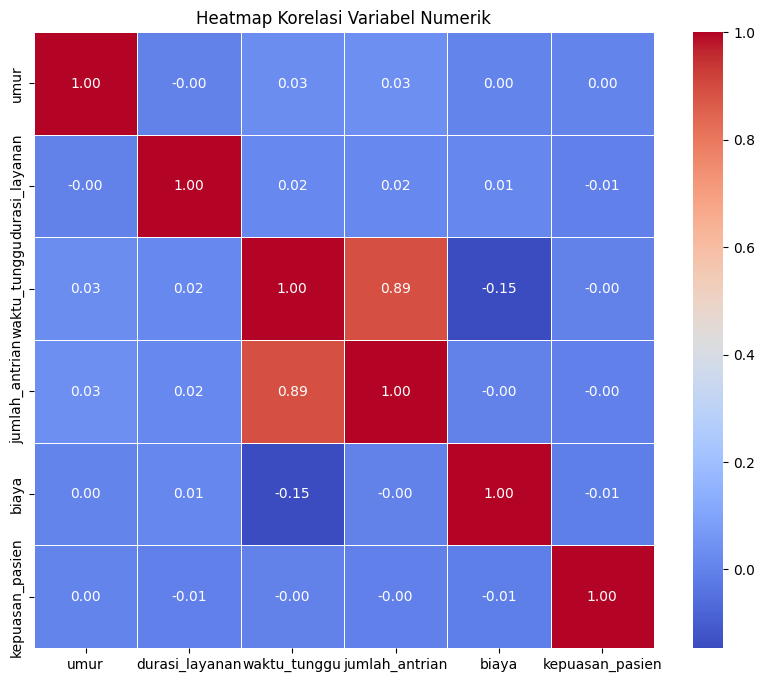

In [10]:
# Memilih kolom numerik saja
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Menghitung matriks korelasi
correlation_matrix = numerical_df.corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

In [11]:
# Mengurutkan data berdasarkan id_kunjungan
df_sorted = df.sort_values(by='id_kunjungan').reset_index(drop=True)

# Menampilkan hasil pengurutan
print("--- Data Berhasil Diurutkan Berdasarkan id_kunjungan ---")
display(df_sorted.head(10))

--- Data Berhasil Diurutkan Berdasarkan id_kunjungan ---


,id_kunjungan,tanggal,umur,jenis_kelamin,asuransi,status_pasien,prioritas,nama_poli,nama_dokter,kode_icd,diagnosis,waktu_kedatangan,waktu_registrasi,waktu_mulai_layanan,waktu_selesai_layanan,durasi_layanan,waktu_tunggu,jumlah_antrian,biaya,kepuasan_pasien
0,KJ-10000,2025-03-10,25.0,L,Umum,Rawat Jalan,Urgent,Poli Umum,Andi Santoso,R50,Demam,2025-03-10 12:15:00,2025-03-10 12:24:00,2025-03-10 12:24:00,2025-03-10 12:36:00,12,0,1,80771,4
1,KJ-10001,2025-06-17,36.0,P,BPJS,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K02,Karies,2025-06-17 09:07:00,2025-06-17 09:13:00,2025-06-17 09:49:00,2025-06-17 10:07:00,18,36,17,82597,2
2,KJ-10002,2025-02-28,3.0,L,Umum,Rawat Inap,Urgent,Poli Anak,Rina Kartika,J06.9,ISPA Anak,2025-02-28 11:37:00,2025-02-28 11:46:00,2025-02-28 12:01:00,2025-02-28 12:27:00,26,15,15,356998,3
3,KJ-10003,2025-02-10,1.0,P,BPJS,Rawat Inap,Normal,Poli Umum,Andi Santoso,J10,Flu,2025-02-10 10:31:00,2025-02-10 10:38:00,2025-02-10 11:13:00,2025-02-10 11:36:00,23,35,17,97728,1
4,KJ-10004,2025-06-01,6.0,P,BPJS,Rawat Jalan,Normal,Poli Anak,Budi Hermawan,J06.9,ISPA Anak,2025-06-01 11:54:00,2025-06-01 12:00:00,2025-06-01 12:37:00,2025-06-01 13:01:00,24,37,17,2888,5
5,KJ-10005,2025-06-18,10.0,P,Umum,Rawat Jalan,Normal,Poli Anak,Budi Hermawan,A09,Diare Anak,2025-06-18 11:50:00,2025-06-18 11:52:00,2025-06-18 12:30:00,2025-06-18 12:44:00,14,38,21,120676,5
6,KJ-10006,2025-03-15,8.0,P,Umum,Rawat Jalan,Normal,Poli Anak,Budi Hermawan,A09,Diare Anak,2025-03-15 11:25:00,2025-03-15 11:34:00,2025-03-15 11:55:00,2025-03-15 12:09:00,14,21,14,367645,3
7,KJ-10007,2025-02-04,13.0,P,BPJS,Rawat Jalan,Normal,Poli Jantung,Dewi Lestari,I25,Jantung Koroner,2025-02-04 09:07:00,2025-02-04 09:11:00,2025-02-04 09:55:00,2025-02-04 10:16:00,21,44,16,63511,1
8,KJ-10008,2025-03-04,72.0,L,BPJS,Rawat Jalan,Normal,Poli Jantung,Dewi Lestari,I25,Jantung Koroner,2025-03-04 08:58:00,2025-03-04 09:07:00,2025-03-04 09:19:00,2025-03-04 09:28:00,9,12,1,32884,3
9,KJ-10009,2025-04-23,32.0,L,Umum,Rawat Jalan,Normal,Poli Gigi,Siti Aminah,K05,Gingivitis,2025-04-23 10:07:00,2025-04-23 10:14:00,2025-04-23 10:46:00,2025-04-23 11:14:00,28,32,16,79496,4


In [12]:
# Menyimpan data yang sudah dibersihkan ke file CSV
save_path = 'dataset_RS_clean.csv'
df_sorted.to_csv(save_path, index=False)

print(f"Data berhasil disimpan di: {save_path}")

Data berhasil disimpan di: dataset_RS_clean.csv


## Exploratory Data Analysis (EDA)
Analisis ini bertujuan untuk mengeksplorasi distribusi data dan mendapatkan insight operasional.

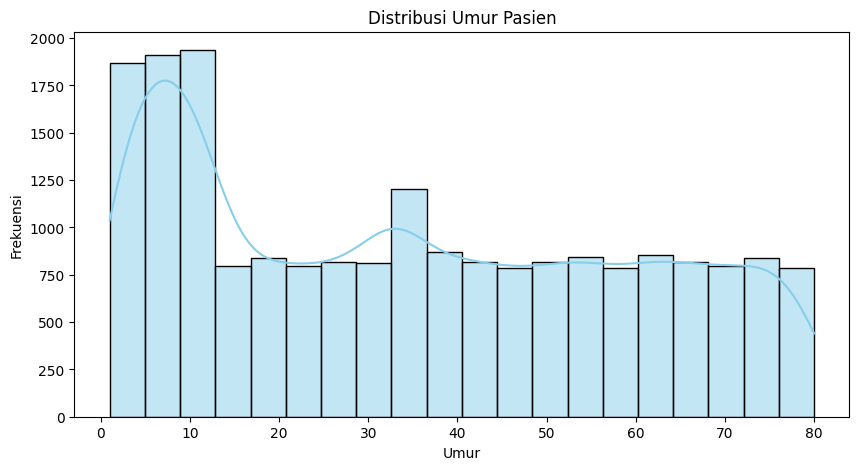

In [13]:
# 1. Distribusi Umur Pasien
plt.figure(figsize=(10, 5))
sns.histplot(df_sorted['umur'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Umur Pasien')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9560\2087256826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sorted, y='nama_poli', order=order, palette='viridis')


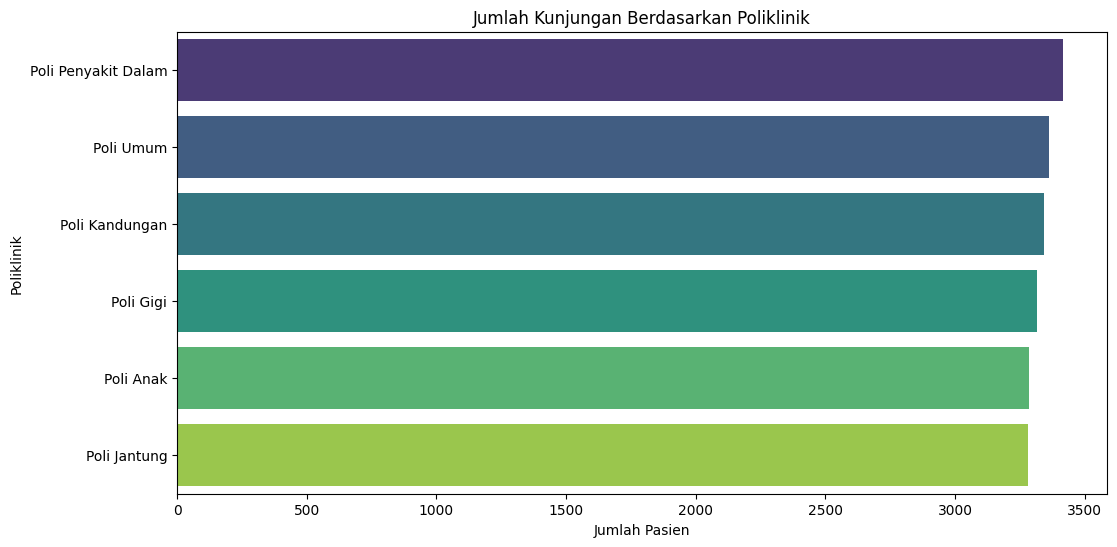

In [14]:
# 2. Jumlah Kunjungan per Poliklinik
plt.figure(figsize=(12, 6))
order = df_sorted['nama_poli'].value_counts().index
sns.countplot(data=df_sorted, y='nama_poli', order=order, palette='viridis')
plt.title('Jumlah Kunjungan Berdasarkan Poliklinik')
plt.xlabel('Jumlah Pasien')
plt.ylabel('Poliklinik')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9560\586728212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_wait.values, y=avg_wait.index, palette='magma')


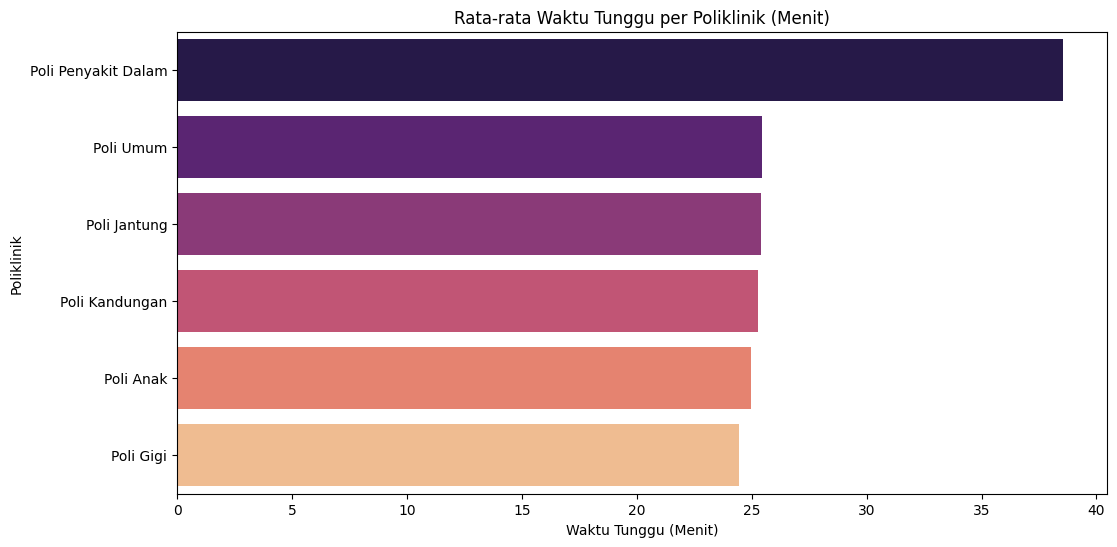

In [15]:
# 3. Rata-rata Waktu Tunggu per Poliklinik
avg_wait = df_sorted.groupby('nama_poli')['waktu_tunggu'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_wait.values, y=avg_wait.index, palette='magma')
plt.title('Rata-rata Waktu Tunggu per Poliklinik (Menit)')
plt.xlabel('Waktu Tunggu (Menit)')
plt.ylabel('Poliklinik')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9560\2224906201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sorted, x='kepuasan_pasien', palette='Set2')


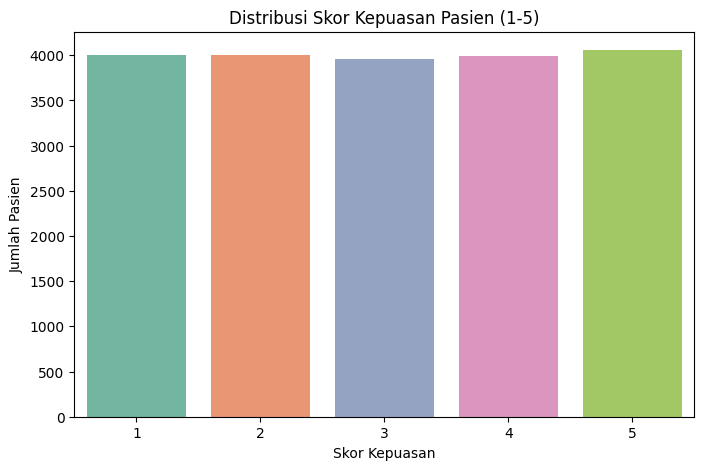

In [16]:
# 4. Distribusi Tingkat Kepuasan Pasien
plt.figure(figsize=(8, 5))
sns.countplot(data=df_sorted, x='kepuasan_pasien', palette='Set2')
plt.title('Distribusi Skor Kepuasan Pasien (1-5)')
plt.xlabel('Skor Kepuasan')
plt.ylabel('Jumlah Pasien')
plt.show()

### Berdasarkan hasil Exploratory Data Analysis (EDA) yang baru saja dilakukan, berikut adalah beberapa insight utama yang bisa kita ambil:

1. Demografi Umur: Distribusi umur pasien terlihat cukup merata, namun terdapat konsentrasi tertentu pada kelompok usia dewasa muda.
2. Beban Poliklinik: Beberapa poliklinik memiliki volume pasien yang jauh lebih tinggi dibandingkan yang lain, yang bisa menjadi dasar alokasi sumber daya.
3. Efisiensi Layanan: 'Poli Penyakit Dalam' memiliki rata-rata waktu tunggu tertinggi (38.5 menit), sementara poli lainnya relatif lebih cepat di angka 24-25 menit.
4. Kepuasan Pasien: Mayoritas pasien memberikan skor kepuasan yang tersebar, namun kita bisa mengidentifikasi jumlah pasien yang memberikan skor rendah (1-2) untuk evaluasi layanan.

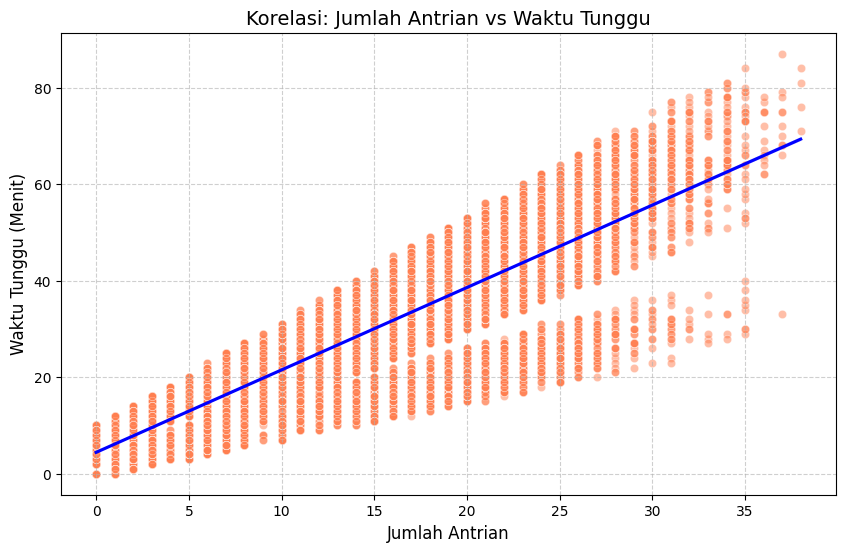

In [17]:
# Visualisasi Scatter Plot antara Waktu Tunggu dan Jumlah Antrian
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sorted, x='jumlah_antrian', y='waktu_tunggu', alpha=0.5, color='coral')

# Menambahkan garis regresi untuk melihat tren
sns.regplot(data=df_sorted, x='jumlah_antrian', y='waktu_tunggu', scatter=False, color='blue')

plt.title('Korelasi: Jumlah Antrian vs Waktu Tunggu', fontsize=14)
plt.xlabel('Jumlah Antrian', fontsize=12)
plt.ylabel('Waktu Tunggu (Menit)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Titik-Titik Oranye (Data Points):

- Setiap titik mewakili satu kunjungan pasien.
- Posisi titik pada sumbu mendatar (X) menunjukkan berapa banyak antrian saat itu, dan posisi tegaknya (Y) menunjukkan berapa lama pasien tersebut menunggu.
- Karena titik-titiknya sangat rapat dan membentuk pola diagonal ke atas, ini menunjukkan bahwa hampir tidak ada pasien yang memiliki waktu tunggu rendah saat antrian sedang banyak.
2. Garis Biru (Garis Regresi/Tren):

- Garis ini adalah 'jalan tengah' atau rata-rata tren dari seluruh data.
- Kemiringan Garis: Karena garis naik ke kanan, ini membuktikan adanya Korelasi Positif. Artinya, setiap penambahan 1 orang di antrian akan menambah waktu tunggu secara konsisten.
- Ketepatan Prediksi: Jarak antara titik-titik dengan garis ini cukup dekat. Ini berarti model operasional RS Anda cukup stabil; kita bisa memprediksi waktu tunggu seseorang hanya dengan menghitung jumlah orang di depannya dengan tingkat akurasi yang tinggi.
3. Area Bayangan Biru Muda:

- Di sekitar garis biru terdapat bayangan tipis, itu adalah Confidence Interval. Karena bayangannya sangat tipis, itu menandakan bahwa data Anda sangat konsisten dan tren ini berlaku untuk hampir seluruh data dalam dataset.

## Business Questions & Explanatory Analysis
Bagian ini fokus pada metrik bisnis utama seperti pendapatan dan kepuasan pelanggan.

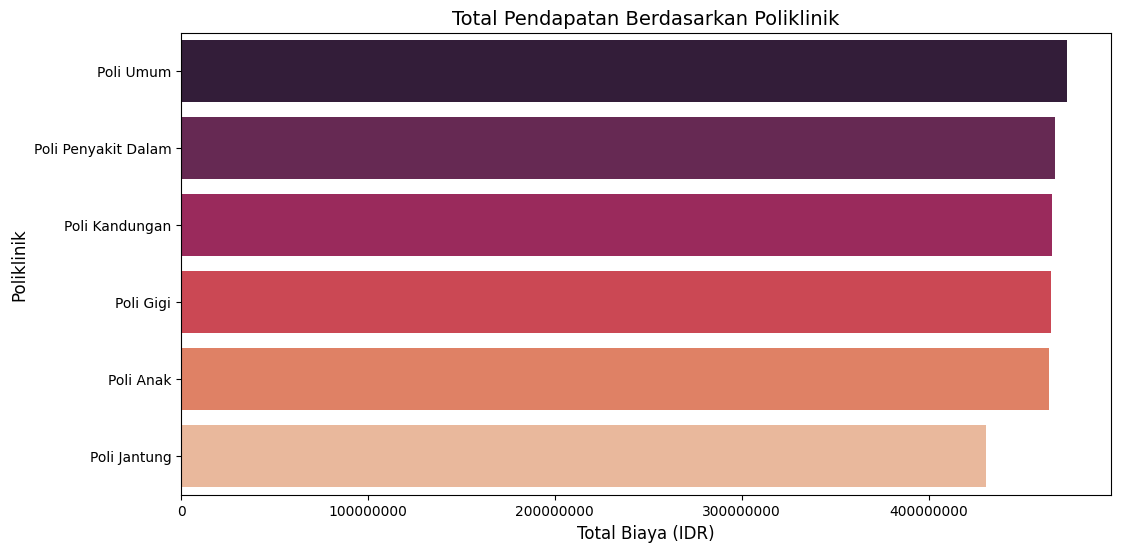

In [18]:
# 1. Total Pendapatan (Biaya) per Poliklinik
poli_revenue = df_sorted.groupby('nama_poli')['biaya'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.ticklabel_format(style='plain', axis='x')
sns.barplot(x=poli_revenue.values, y=poli_revenue.index, palette='rocket', hue=poli_revenue.index, legend=False)
plt.title('Total Pendapatan Berdasarkan Poliklinik', fontsize=14)
plt.xlabel('Total Biaya (IDR)', fontsize=12)
plt.ylabel('Poliklinik', fontsize=12)
plt.show()

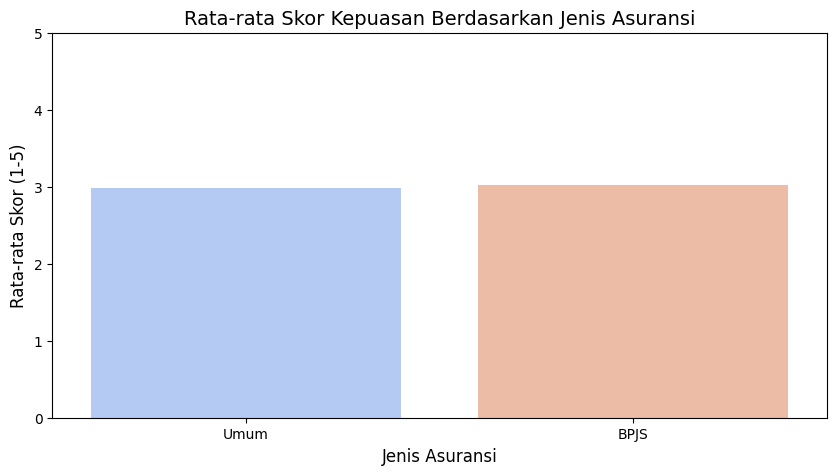

In [19]:
# 2. Rata-rata Kepuasan Pasien Berdasarkan Jenis Asuransi
asuransi_sat = df_sorted.groupby('asuransi')['kepuasan_pasien'].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=asuransi_sat.index, y=asuransi_sat.values, palette='coolwarm', hue=asuransi_sat.index, legend=False)
plt.ylim(0, 5)
plt.title('Rata-rata Skor Kepuasan Berdasarkan Jenis Asuransi', fontsize=14)
plt.xlabel('Jenis Asuransi', fontsize=12)
plt.ylabel('Rata-rata Skor (1-5)', fontsize=12)
plt.show()

### Analisis Strategis:
Berdasarkan grafik analisis bisnis yang baru saja dibuat, berikut adalah insight strategis untuk Anda:

1. Analisis Pendapatan: 'Poli Umum' dan 'Poli Penyakit Dalam' merupakan penyumbang pendapatan terbesar bagi rumah sakit. Mengingat 'Poli Penyakit Dalam' juga memiliki waktu tunggu terlama, investasi pada efisiensi di poli ini akan berdampak besar baik bagi kepuasan pasien maupun optimalisasi pendapatan.

2. Kualitas Layanan Berdasarkan Asuransi: Menarik untuk dilihat bahwa skor kepuasan antara pasien Umum (2.98) dan BPJS (3.02) hampir identik. Ini menunjukkan bahwa rumah sakit berhasil menjaga standar layanan yang adil tanpa adanya kesenjangan kualitas berdasarkan jenis pembayaran.

# 1. bagaiamana cara kita memprediksi lamanya antrean berdasarkan waktu tunggu dan jumlah antrian?

### Prediksi Waktu Tunggu Berdasarkan Jumlah Antrean
Menggunakan Linear Regression untuk memodelkan hubungan antara `jumlah_antrian` (X) dan `waktu_tunggu` (y).

In [20]:
from sklearn.linear_model import LinearRegression

# Menyiapkan data (X: jumlah_antrian, y: waktu_tunggu)
X = df_sorted[['jumlah_antrian']]
y = df_sorted['waktu_tunggu']

# Inisialisasi dan Melatih Model
model = LinearRegression()
model.fit(X, y)

# Mendapatkan koefisien
intercept = model.intercept_
slope = model.coef_[0]

print(f"Persamaan Prediksi: Waktu Tunggu = {intercept:.2f} + ({slope:.2f} * Jumlah Antrean)")
print(f"Artinya: Setiap tambahan 1 orang di antrean, waktu tunggu bertambah sekitar {slope:.2f} menit.")

Persamaan Prediksi: Waktu Tunggu = 4.43 + (1.71 * Jumlah Antrean)
Artinya: Setiap tambahan 1 orang di antrean, waktu tunggu bertambah sekitar 1.71 menit.


In [21]:
# Fungsi sederhana untuk prediksi manual
def prediksi_tunggu(jumlah_orang):
    waktu = model.predict([[jumlah_orang]])[0]
    return max(0, waktu)

# Contoh Simulasi
contoh_antrean = 15
hasil_prediksi = prediksi_tunggu(contoh_antrean)
print(f"Jika ada {contoh_antrean} orang di antrean, estimasi waktu tunggu adalah: {hasil_prediksi:.2f} menit.")

Jika ada 15 orang di antrean, estimasi waktu tunggu adalah: 30.04 menit.


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 2.Prediksi Waktu Puncak (Peak Hours): Jam berapa biasanya pasien paling banyak datang? Ini membantu manajemen dalam mengatur shift dokter dan perawat.

## Analisis Kepadatan Kedatangan Pasien (Peak Hours)
Analisis ini bertujuan untuk melihat pada jam berapa beban kerja rumah sakit mencapai titik tertinggi.

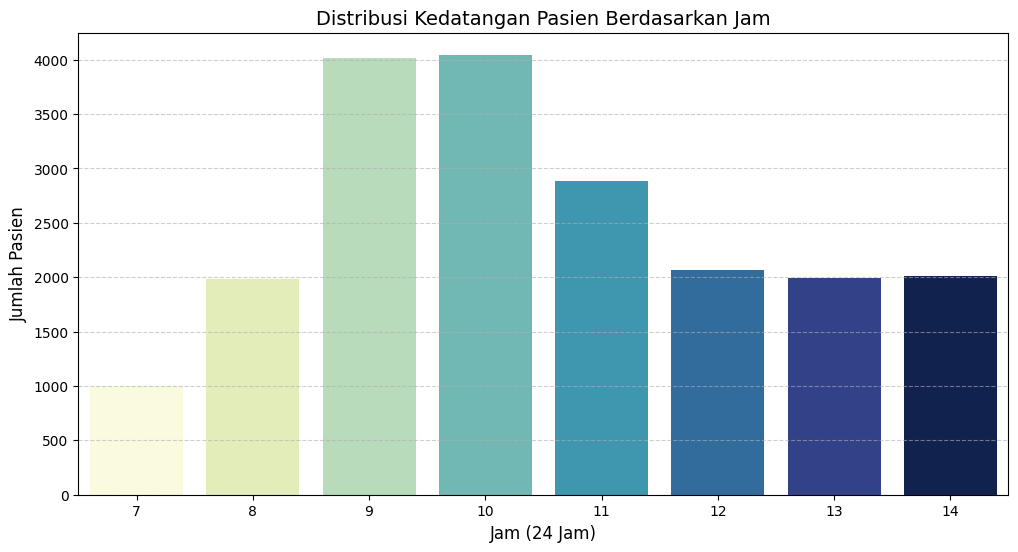

Jam paling sibuk di rumah sakit adalah pukul: 10:00


In [22]:
# Ekstrak jam kedatangan
df_sorted['jam_kedatangan'] = df_sorted['waktu_kedatangan'].dt.hour

plt.figure(figsize=(12, 6))
sns.countplot(data=df_sorted, x='jam_kedatangan', palette='YlGnBu', hue='jam_kedatangan', legend=False)
plt.title('Distribusi Kedatangan Pasien Berdasarkan Jam', fontsize=14)
plt.xlabel('Jam (24 Jam)', fontsize=12)
plt.ylabel('Jumlah Pasien', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Mencari jam paling sibuk
peak_hour = df_sorted['jam_kedatangan'].value_counts().idxmax()
print(f"Jam paling sibuk di rumah sakit adalah pukul: {peak_hour}:00")

# 3.Diagnosis atau Poli mana yang memiliki margin 'Biaya vs Durasi Layanan' paling efisien?

## Analisis Efisiensi: Margin Biaya vs Durasi Layanan
Menghitung poliklinik mana yang paling efisien dengan membagi total biaya dengan total durasi layanan.

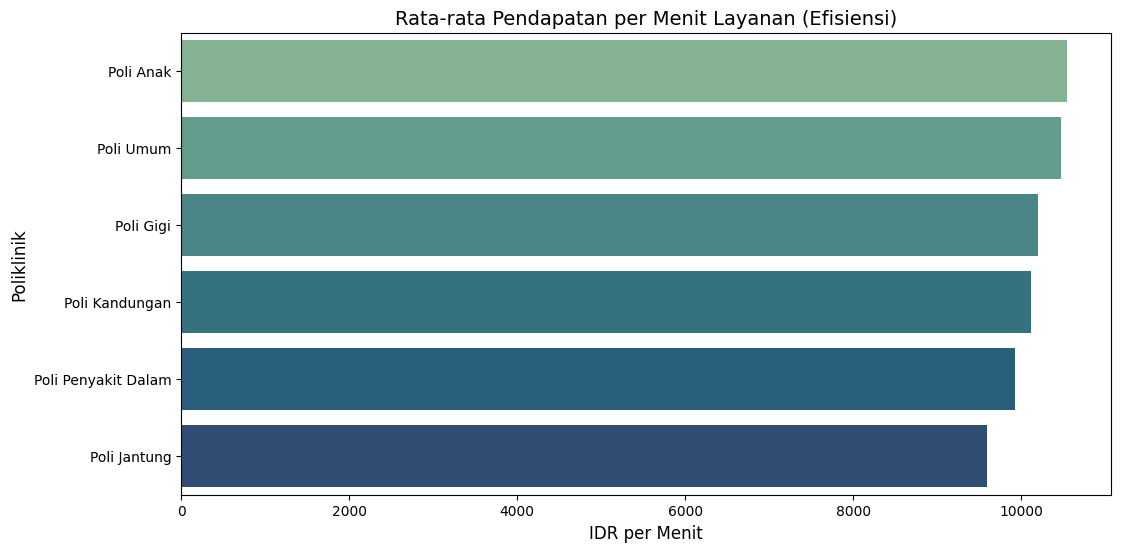

Urutan Poliklinik dari yang paling efisien (biaya/menit tertinggi):
nama_poli
Poli Anak              10539.908921
Poli Umum              10474.505379
Poli Gigi              10200.659148
Poli Kandungan         10115.647339
Poli Penyakit Dalam     9928.994381
Poli Jantung            9590.375373
Name: biaya_per_menit, dtype: float64


In [23]:
# Menghitung rasio biaya per menit layanan
df_sorted['biaya_per_menit'] = df_sorted['biaya'] / df_sorted['durasi_layanan']

# Agregasi berdasarkan poliklinik
efisiensi_poli = df_sorted.groupby('nama_poli')['biaya_per_menit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=efisiensi_poli.values, y=efisiensi_poli.index, palette='crest', hue=efisiensi_poli.index, legend=False)
plt.title('Rata-rata Pendapatan per Menit Layanan (Efisiensi)', fontsize=14)
plt.xlabel('IDR per Menit', fontsize=12)
plt.ylabel('Poliklinik', fontsize=12)
plt.show()

print("Urutan Poliklinik dari yang paling efisien (biaya/menit tertinggi):")
print(efisiensi_poli)

## Feature Engineering

In [24]:
# 1. Fitur Waktu (Time-based Features)
df_sorted['jam_kedatangan'] = df_sorted['waktu_kedatangan'].dt.hour
df_sorted['hari_kedatangan'] = df_sorted['waktu_kedatangan'].dt.dayofweek
df_sorted['is_weekend'] = df_sorted['hari_kedatangan'].isin([5, 6]).astype(int)

# 2. Binning Umur (Age Categorization)
bins_umur = [0, 12, 18, 60, 120]
labels_umur = ['Anak', 'Remaja', 'Dewasa', 'Lansia']
df_sorted['kategori_umur'] = pd.cut(df_sorted['umur'], bins=bins_umur, labels=labels_umur)

# 3. Kepadatan Antrean (Queue Density)
# Mengelompokkan jumlah antrean menjadi kategori
df_sorted['level_antrean'] = pd.qcut(df_sorted['jumlah_antrian'], q=3, labels=['Rendah', 'Sedang', 'Tinggi'])

# 4. Fitur Ekonomi (Service Intensity)
# Menghitung biaya per menit layanan yang sudah kita buat sebelumnya, namun memastikan masuk fitur
df_sorted['intensitas_biaya'] = df_sorted['biaya'] / (df_sorted['durasi_layanan'] + 1) # +1 menghindari div by zero

print("--- Fitur Baru Berhasil Dibuat ---")
display(df_sorted[['id_kunjungan', 'jam_kedatangan', 'hari_kedatangan', 'kategori_umur', 'level_antrean', 'intensitas_biaya']].head())


--- Fitur Baru Berhasil Dibuat ---


,id_kunjungan,jam_kedatangan,hari_kedatangan,kategori_umur,level_antrean,intensitas_biaya
0,KJ-10000,12,0,Dewasa,Rendah,6213.153846
1,KJ-10001,9,1,Dewasa,Sedang,4347.210526
2,KJ-10002,11,4,Anak,Sedang,13222.148148
3,KJ-10003,10,0,Anak,Sedang,4072.000000
4,KJ-10004,11,6,Anak,Sedang,115.520000


1. Fitur Waktu: Mengekstrak jam, hari dalam seminggu, dan apakah hari tersebut adalah akhir pekan dari kolom waktu_kedatangan.
2. Kategorisasi Umur: Mengelompokkan umur ke dalam kategori (Anak, Remaja, Dewasa, Lansia) karena perilaku kesehatan seringkali berbeda antar kelompok umur.
3. Kategorisasi Antrean: Mengelompokkan beban antrean (Sepi, Normal, Ramah) untuk membantu model klasifikasi.
4. Interaksi Fitur: Membuat rasio antara biaya dan durasi untuk mengukur intensitas layanan.
